# Performer Attention Head Replacement in TinyLlama 1.1B Model - Analysis

This notebook benchmarks FAVOR+ (Performer) attention vs standard softmax attention inside TinyLlama 1.1B.

- **Section A** - Per-token quality comparison (KL divergence, token match)
- **Section B** - Speed benchmarks: B1 prefill O(N^2) vs O(NM), B2 decode O(N) vs O(M)
- **Section C** - Mixed-head quality sweep (0 to 32 performer heads)
- **Section D** - Independent text generation side-by-side
- **Section E** - Complexity convergence: E1 small-N regime, E2 M approaching N
- **Section F** - Approximation quality: F1 vary M (quality improves), F2 vary N (quality vs length)

## Setup

In [1]:
!git clone https://github.com/Antoinechss/Performer-attention-LLM.git
!pip install -q transformers accelerate sentencepiece protobuf

# IMPORTANT: Do NOT %cd into the repo — the local transformers/ folder
# would shadow the pip-installed HuggingFace transformers package.
REPO_DIR = "/content/Performer-attention-LLM"

import torch
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Triton available: ", end="")
try:
    import triton; print("Yes")
except ImportError:
    print("No")

Cloning into 'Performer-attention-LLM'...
remote: Enumerating objects: 239, done.
remote: Counting objects: 100% (239/239), done.
remote: Compressing objects: 100% (179/179), done.
remote: Total 239 (delta 82), reused 208 (delta 54), pack-reused 0 (from 0)
Receiving objects: 100% (239/239), 1.20 MiB | 5.84 MiB/s, done.
Resolving deltas: 100% (82/82), done.
GPU: Tesla T4
Triton available: Yes


In [2]:
import sys, os, time
import torch
import torch.nn.functional as F

# Only add performer/ to path — NOT the repo root
sys.path.insert(0, os.path.join(REPO_DIR, 'performer'))
from performer_attention import PerformerAttentionCore, _HAS_TRITON

# ── Config ──────────────────────────────────────────────────────
MODEL          = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
PROMPT         = "<|user|>\nHow do I get a good night's sleep?</s>\n<|assistant|>\n"
MAX_NEW_TOKENS = 30
DTYPE          = torch.float16
DEVICE         = "cuda"

print(f"Triton kernel loaded: {_HAS_TRITON}")
print(f"Device: {DEVICE}, dtype: {DTYPE}")

Triton kernel loaded: True
Device: cuda, dtype: torch.float16


In [3]:
# ── Mixed Performer Attention wrapper (monkey-patches HF LlamaAttention) ────

class MixedPerformerAttention(torch.nn.Module):
    """Wraps a HuggingFace LlamaAttention, routing some heads through FAVOR+."""

    def __init__(self, original_attn, num_performer_heads):
        super().__init__()
        self.original = original_attn
        self.head_dim = original_attn.head_dim
        self.num_heads = original_attn.config.num_attention_heads
        self.num_key_value_heads = original_attn.config.num_key_value_heads
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.scaling = self.head_dim ** -0.5
        self.num_performer_heads = num_performer_heads
        self.num_standard_heads = self.num_heads - num_performer_heads

        self.q_proj = original_attn.q_proj
        self.k_proj = original_attn.k_proj
        self.v_proj = original_attn.v_proj
        self.o_proj = original_attn.o_proj

        self.performer_core = PerformerAttentionCore(
            head_dim=self.head_dim, num_features=256
        ).to(DEVICE)

        self.config = original_attn.config
        self.layer_idx = original_attn.layer_idx
        self.is_causal = True

    def _rotate_half(self, x):
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat((-x2, x1), dim=-1)

    def _apply_rotary(self, q, k, cos, sin):
        cos = cos.unsqueeze(1)
        sin = sin.unsqueeze(1)
        return (q * cos) + (self._rotate_half(q) * sin), (k * cos) + (self._rotate_half(k) * sin)

    def forward(self, hidden_states, position_embeddings=None,
                attention_mask=None, past_key_values=None, **kwargs):
        B, N, _ = hidden_states.shape

        q = self.q_proj(hidden_states).view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(hidden_states).view(B, N, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(hidden_states).view(B, N, self.num_key_value_heads, self.head_dim).transpose(1, 2)

        cos, sin = position_embeddings
        q, k = self._apply_rotary(q, k, cos, sin)

        if past_key_values is not None:
            k, v = past_key_values.update(k, v, self.layer_idx)

        if self.num_key_value_groups > 1:
            k = k.repeat_interleave(self.num_key_value_groups, dim=1)
            v = v.repeat_interleave(self.num_key_value_groups, dim=1)

        if self.num_standard_heads == 0:
            attn_out = self.performer_core(q, k, v)
        elif self.num_performer_heads == 0:
            scores = torch.matmul(q, k.transpose(-2, -1)) * self.scaling
            if attention_mask is not None:
                scores = scores + attention_mask
            w = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q.dtype)
            attn_out = torch.matmul(w, v)
        else:
            Kp = self.num_performer_heads
            out_p = self.performer_core(q[:, :Kp], k[:, :Kp], v[:, :Kp])

            q_s, k_s, v_s = q[:, Kp:], k[:, Kp:], v[:, Kp:]
            scores = torch.matmul(q_s, k_s.transpose(-2, -1)) * self.scaling
            if attention_mask is not None:
                scores = scores + attention_mask
            w = torch.softmax(scores, dim=-1, dtype=torch.float32).to(q_s.dtype)
            out_s = torch.matmul(w, v_s)
            attn_out = torch.cat([out_p, out_s], dim=1)

        attn_out = attn_out.transpose(1, 2).contiguous().reshape(B, N, -1)
        return self.o_proj(attn_out), None

In [4]:
# ── Load models ─────────────────────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM
import copy

print("Classic Model Load")
std_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE, device_map=DEVICE)
std_model.eval()

num_heads = std_model.config.num_attention_heads
### Tune number of attention heads replaced: ###
SECTION_A_PERFORMER_HEADS = 4

print("Performer Model Load")
perf_model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=DTYPE, device_map=DEVICE)
perf_model.eval()

# Monkey-patch attention layers
for layer in perf_model.model.layers:
    layer.self_attn = MixedPerformerAttention(
        layer.self_attn, num_performer_heads=SECTION_A_PERFORMER_HEADS
    )

tokenizer = AutoTokenizer.from_pretrained(MODEL)
prompt_ids = tokenizer(PROMPT, return_tensors="pt")["input_ids"].to(DEVICE)

print(f"Models loaded. Heads replaced: {SECTION_A_PERFORMER_HEADS}/{num_heads} performer.")

Classic Model Load


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Models loaded. Heads replaced: 4/32 performer.


## Per-token quality comparison

Generates tokens step-by-step, comparing output distributions between standard and performer (4/32 performer heads)

In [30]:

for layer in perf_model.model.layers:
    layer.self_attn.num_performer_heads = SECTION_A_PERFORMER_HEADS
    layer.self_attn.num_standard_heads  = num_heads - SECTION_A_PERFORMER_HEADS


print(f"Generation benchmark [{SECTION_A_PERFORMER_HEADS}/{num_heads} performer heads]")
print(" ")

W = 14
hdr = f"{'Step':>4}  {'Classic':.<{W}}  {'Performer':.<{W}}  {'p(cls)':>7}  {'p_perf(cls)':>11}  {'KL':>6}"
print(hdr)
print("-" * len(hdr))

current_ids = prompt_ids.clone()
classic_tokens, perf_tokens = [], []
kl_per_step = []

with torch.no_grad():
    for step in range(1, MAX_NEW_TOKENS + 1):
        std_out  = std_model(input_ids=current_ids,  use_cache=False)
        perf_out = perf_model(input_ids=current_ids, use_cache=False)

        std_logits  = std_out.logits[0, -1].float()
        perf_logits = perf_out.logits[0, -1].float()
        std_probs  = F.softmax(std_logits,  dim=-1)
        perf_probs = F.softmax(perf_logits, dim=-1)

        classic_id = std_logits.argmax().item()
        perf_id    = perf_logits.argmax().item()
        classic_p  = std_probs[classic_id].item()
        perf_p_cls = perf_probs[classic_id].item()
        kl         = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()

        c_tok = repr(tokenizer.decode([classic_id]))[1:-1]
        p_tok = repr(tokenizer.decode([perf_id]))[1:-1]
        print(f"{step:>4}  {c_tok:<{W}}  {p_tok:<{W}}  {classic_p:>6.1%}  {perf_p_cls:>11.1%}  {kl:>6.2f}")

        classic_tokens.append(classic_id)
        perf_tokens.append(perf_id)
        kl_per_step.append(kl)

        current_ids = torch.cat([current_ids, torch.tensor([[classic_id]], device=DEVICE)], dim=-1)
        if classic_id == tokenizer.eos_token_id:
            break

n = len(classic_tokens)
print(f"\n  Classic:   {tokenizer.decode(classic_tokens, skip_special_tokens=True)}")
print(f"  Performer: {tokenizer.decode(perf_tokens, skip_special_tokens=True)}")
match = sum(c == p for c, p in zip(classic_tokens, perf_tokens))
print(f"  Match: {match}/{n}  |  Avg KL: {sum(kl_per_step)/n:.3f}")

Generation benchmark [4/32 performer heads]
 
Step  Classic.......  Performer.....   p(cls)  p_perf(cls)      KL
------------------------------------------------------------------
   1  To              ,                29.2%         0.0%   10.08
   2  get             ,                96.3%         0.1%    7.30
   3  a               ,                95.2%         1.4%    4.25
   4  good            ,                99.7%         0.0%    8.07
   5  night           ,                99.9%         0.0%   10.60
   6  '               ,                99.9%         1.3%    4.36
   7  s               s               100.0%         5.8%    2.85
   8  sleep           ,                99.9%         0.0%    7.80
   9  ,               ,                98.6%        14.5%    1.88
  10  here            the              24.1%         0.0%    6.17
  11  are             :                99.4%         0.2%    6.43
  12  some            :                89.6%         0.0%    9.91
  13  tips            ss    

## Speed benchmarks (GPU + Triton)

In [28]:

try:
    from triton_scan import triton_scan_forward as _triton_scan_raw
    from triton_scan import triton_decode_forward as _triton_decode_raw
except ImportError:
    _triton_scan_raw = _triton_decode_raw = None

_CUDA = torch.cuda.is_available()
_dev  = torch.device("cuda" if _CUDA else "cpu")
_TRITON = _HAS_TRITON and _CUDA

H, D     = 32, 64
M_VALS   = [128, 256]
REPEATS  = 10
scale    = D ** -0.25

performer_cores = {m: PerformerAttentionCore(head_dim=D, num_features=m).to(_dev) for m in M_VALS}

def time_fn(fn, repeats=REPEATS):
    # Warmup
    fn()
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(repeats):
        fn()
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / repeats * 1000

# PREFILL

print(f"Prefill step  |  H={H} D={D}  using GPU + Triton kernels")
print(" ")

SEQ_LENS = [256, 512, 1024, 2048, 4096]
_CW = 12

hdr = f"{'N':>6}  {'Classic (ms)':>8}" + "".join(f"  {'Perf M='+str(m):>{_CW}}" for m in M_VALS) + f"  {'speedup':>8}"
print(hdr)
print("-" * len(hdr))

b1_results = []
with torch.no_grad():
    for N in SEQ_LENS:
        q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

        def std_attn():
            w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v)

        std_ms = time_fn(std_attn)
        row = f"{N:>6}  {std_ms:>7.2f}"

        e2e_times = {}
        for m in M_VALS:
            core = performer_cores[m]
            fn = lambda c=core: c(q, k, v)
            e2e_times[m] = time_fn(fn)
            row += f"  {e2e_times[m]:>{_CW}.2f}"

        best = min(e2e_times.values())
        speedup = std_ms / best
        row += f"  {speedup:>7.2f}x"
        print(row)
        b1_results.append((N, std_ms, e2e_times, speedup))

Prefill step  |  H=32 D=64  using GPU + Triton kernels
 
     N  Classic (ms)    Perf M=128    Perf M=256   speedup
----------------------------------------------------------
   256     0.35          1.57          2.24     0.22x
   512     0.66          2.64          4.28     0.25x
  1024     2.12          4.09          6.01     0.52x
  2048     8.56          7.79         10.38     1.10x
  4096    42.65         13.32         20.59     3.20x


In [29]:
# DECODE

print(f"Decode step using GPU + Triton Kernels")
print("")

CACHE_SIZES = [64, 256, 1024, 4096]
_CW = 12

hdr2 = f"{'Context':>6}  {'Classic':>8}" + "".join(f"  {'Perf M='+str(m):>{_CW}}" for m in M_VALS) + f"  {'speedup':>8}"
print(hdr2)
print("-" * len(hdr2))

with torch.no_grad():
    for N in CACHE_SIZES:
        q_new = torch.randn(1, H, 1, D, device=_dev, dtype=torch.float32)
        k_all = torch.randn(1, H, N, D, device=_dev, dtype=torch.float32)
        v_all = torch.randn(1, H, N, D, device=_dev, dtype=torch.float32)

        def std_decode():
            w = torch.softmax(torch.matmul(q_new, k_all.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v_all)

        std_ms = time_fn(std_decode)
        row = f"{N:>6}  {std_ms:>7.3f}"

        best_perf = float('inf')
        for m in M_VALS:
            core      = performer_cores[m]
            phi_k_all = core.phi(k_all * scale, is_query=False)
            kv_state  = torch.einsum("bhnm,bhnd->bhmd", phi_k_all, v_all).float()
            k_state   = phi_k_all.sum(dim=2).float()
            omega_m   = core.omega.float()

            if _TRITON and _triton_decode_raw is not None:
                fn = lambda kv=kv_state, ks=k_state, om=omega_m: \
                    _triton_decode_raw((q_new * scale).float(), om, kv, ks)
            else:
                def fn(kv=kv_state, ks=k_state, c=core):
                    phi_q = c.phi(q_new * scale, is_query=True)
                    out   = torch.einsum("bhnm,bhmd->bhnd", phi_q, kv)
                    denom = torch.einsum("bhnm,bhm->bhn", phi_q, ks) + 1e-6
                    return out / denom.unsqueeze(-1)

            t = time_fn(fn)
            best_perf = min(best_perf, t)
            row += f"  {t:>{_CW}.3f}"

        row += f"  {std_ms/best_perf:>7.2f}x"
        print(row)

Decode step using GPU + Triton Kernels

Context   Classic    Perf M=128    Perf M=256   speedup
-------------------------------------------------------
    64    0.112         0.341         0.657     0.33x
   256    0.108         0.354         0.638     0.31x
  1024    0.121         0.307         0.551     0.39x
  4096    0.400         0.400         0.551     1.00x


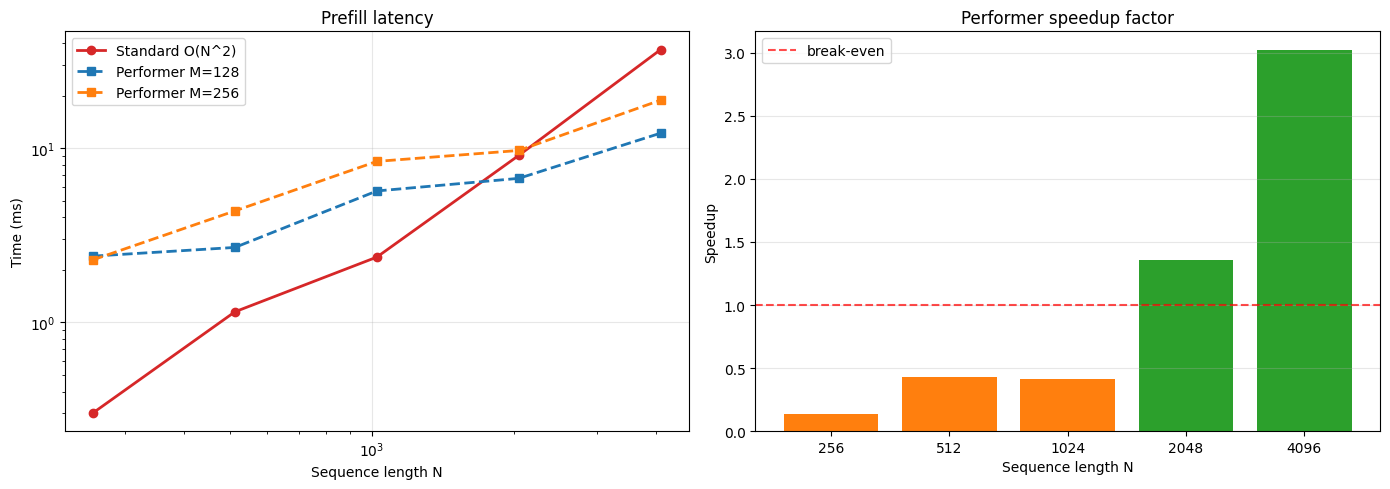

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot B1: Prefill scaling
ax = axes[0]
ns = [r[0] for r in b1_results]
std_times = [r[1] for r in b1_results]
ax.plot(ns, std_times, 'o-', label='Standard O(N^2)', linewidth=2, color='tab:red')
for m in M_VALS:
    perf_times = [r[2][m] for r in b1_results]
    ax.plot(ns, perf_times, 's--', label=f'Performer M={m}', linewidth=2)
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Time (ms)')
ax.set_title('Prefill latency')
ax.legend()
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Plot speedup
ax2 = axes[1]
speedups = [r[3] for r in b1_results]
ax2.bar([str(n) for n in ns], speedups, color=['tab:green' if s > 1 else 'tab:orange' for s in speedups])
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='break-even')
ax2.set_xlabel('Sequence length N')
ax2.set_ylabel('Speedup')
ax2.set_title('Performer speedup factor')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Complexity convergence confirmation

Two experiments that confirm the theoretical O(N*M) vs O(N^2) scaling:

**E1 — Fix M, vary N (small N regime):** When N is small, the quadratic cost N^2 is cheap, so performer (which has overhead from phi() projection + scan) offers no speedup. The crossover point depends on M.

**E2 — Fix N, vary M toward N:** As M approaches N, the performer cost O(N*M) approaches O(N^2) — the same as standard attention. The speedup should converge to ~1x (or below, due to overhead).

In [32]:
# ═══════════════════════════════════════════════════════════════════
# E1 — Fix M, sweep N from small to large
#       Shows: performer has no advantage at small N, crossover emerges
# ═══════════════════════════════════════════════════════════════════

E1_N_VALS = [32, 64, 128, 256, 512, 1024, 2048, 4096]
E1_M_VALS = [64, 128]


print(f"Fix M, vary N  |  H={H} D={D}")
print("")

hdr = f"{'N':>6}  {'Classic':>8}" + "".join(f"  {'Performer M='+str(m):>10}" for m in E1_M_VALS)
print(hdr)
print("-" * len(hdr))

e1_results = []  # list of (N, std_ms, {m: perf_ms})

with torch.no_grad():
    for N in E1_N_VALS:
        q = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        k = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)
        v = torch.randn(1, H, N, D, device=_dev, dtype=torch.float16)

        def std_attn():
            w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
            return torch.matmul(w, v)

        std_ms = time_fn(std_attn)
        row = f"{N:>6}  {std_ms:>7.2f}"

        perf_times = {}
        for m in E1_M_VALS:
            if m not in performer_cores:
                performer_cores[m] = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
            core = performer_cores[m]
            fn = lambda c=core: c(q, k, v)
            perf_times[m] = time_fn(fn)
            row += f"  {perf_times[m]:>9.2f}"

        print(row)
        e1_results.append((N, std_ms, perf_times))

Fix M, vary N  |  H=32 D=64

     N   Classic  Performer M=64  Performer M=128
-------------------------------------------------
    32     0.16       1.10       1.12
    64     0.15       1.24       1.12
   128     0.14       1.16       1.08
   256     0.21       1.91       1.37
   512     0.65       3.59       2.65
  1024     2.37       5.81       3.17
  2048     8.49      10.04       6.20
  4096    43.11      17.47      12.70


In [33]:

E2_N = 2048
E2_M_VALS = [32, 64, 128, 256, 512, 1024, 2048]


print(f"Fix N={E2_N}, vary M toward N")
print("")

# Standard attention baseline for this N
with torch.no_grad():
    q = torch.randn(1, H, E2_N, D, device=_dev, dtype=torch.float16)
    k = torch.randn(1, H, E2_N, D, device=_dev, dtype=torch.float16)
    v = torch.randn(1, H, E2_N, D, device=_dev, dtype=torch.float16)

    def std_attn():
        w = torch.softmax(torch.matmul(q, k.transpose(-2, -1)) * (D ** -0.5), dim=-1)
        return torch.matmul(w, v)

    e2_std_ms = time_fn(std_attn)

print(f"Standard attention at N={E2_N}: {e2_std_ms:.2f} ms\n")
print(f"{'M':>6}  {'M/N':>6}  {'Performer':>9}  {'Speedup':>8}  {'Ratio':>8}")
print("-" * 45)

e2_results = []  # list of (M, perf_ms, speedup)

with torch.no_grad():
    for m in E2_M_VALS:
        if m not in performer_cores:
            performer_cores[m] = PerformerAttentionCore(head_dim=D, num_features=m).to(_dev)
        core = performer_cores[m]
        fn = lambda c=core: c(q, k, v)
        perf_ms = time_fn(fn)
        speedup = e2_std_ms / perf_ms
        ratio = m / E2_N

        print(f"{m:>6}  {ratio:>5.2f}  {perf_ms:>8.2f}  {speedup:>7.2f}x  {'<-- M=N' if m == E2_N else ''}")
        e2_results.append((m, perf_ms, speedup))

Fix N=2048, vary M toward N

Standard attention at N=2048: 9.62 ms

     M     M/N  Performer   Speedup     Ratio
---------------------------------------------
    32   0.02      5.24     1.83x  
    64   0.03     10.01     0.96x  
   128   0.06      6.93     1.39x  
   256   0.12     10.24     0.94x  
   512   0.25    144.59     0.07x  
  1024   0.50    671.47     0.01x  
  2048   1.00   1336.91     0.01x  <-- M=N


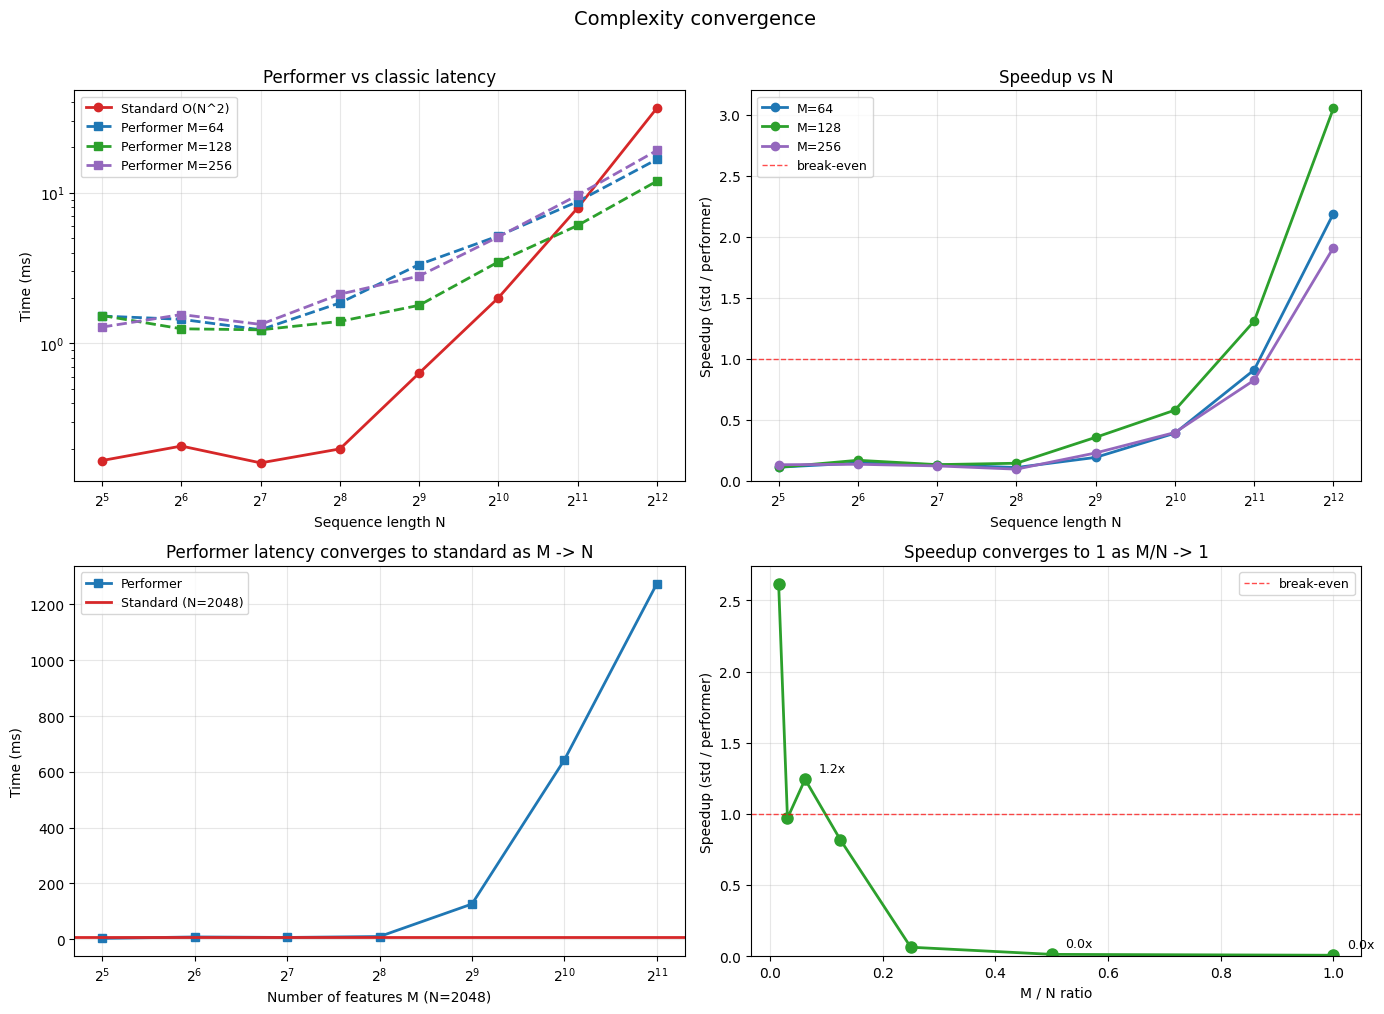

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── E1 Plot 1: Latency curves (log-log) ────────────────────────
ax = axes[0, 0]
e1_ns = [r[0] for r in e1_results]
e1_std = [r[1] for r in e1_results]
ax.plot(e1_ns, e1_std, 'o-', label='Standard O(N^2)', linewidth=2, color='tab:red')
colors = ['tab:blue', 'tab:green', 'tab:purple']
for i, m in enumerate(E1_M_VALS):
    perf = [r[2][m] for r in e1_results]
    ax.plot(e1_ns, perf, 's--', label=f'Performer M={m}', linewidth=2, color=colors[i])
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Time (ms)')
ax.set_title('Performer vs classic latency')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# ── E1 Plot 2: Speedup vs N (shows crossover point) ────────────
ax = axes[0, 1]
for i, m in enumerate(E1_M_VALS):
    speedups = [r[1] / r[2][m] for r in e1_results]
    ax.plot(e1_ns, speedups, 'o-', label=f'M={m}', linewidth=2, color=colors[i])
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='break-even')
ax.set_xlabel('Sequence length N')
ax.set_ylabel('Speedup (std / performer)')
ax.set_title('Speedup vs N')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# ── E2 Plot 1: Latency vs M (approaching N) ────────────────────
ax = axes[1, 0]
e2_ms = [r[0] for r in e2_results]
e2_perf = [r[1] for r in e2_results]
ax.plot(e2_ms, e2_perf, 's-', label='Performer', linewidth=2, color='tab:blue')
ax.axhline(y=e2_std_ms, color='tab:red', linewidth=2, label=f'Standard (N={E2_N})')
ax.set_xlabel(f'Number of features M (N={E2_N})')
ax.set_ylabel('Time (ms)')
ax.set_title('Performer latency converges to standard as M -> N')
ax.legend(fontsize=9)
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

# ── E2 Plot 2: Speedup vs M/N ratio ────────────────────────────
ax = axes[1, 1]
e2_ratios = [m / E2_N for m in e2_ms]
e2_speedups = [r[2] for r in e2_results]
ax.plot(e2_ratios, e2_speedups, 'o-', linewidth=2, color='tab:green', markersize=8)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='break-even')
ax.set_xlabel('M / N ratio')
ax.set_ylabel('Speedup (std / performer)')
ax.set_title('Speedup converges to 1 as M/N -> 1')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
# Mark key points
for ratio, sp in zip(e2_ratios, e2_speedups):
    if ratio in [0.0625, 0.5, 1.0]:
        ax.annotate(f'{sp:.1f}x', (ratio, sp), textcoords="offset points",
                    xytext=(10, 5), fontsize=9)

plt.suptitle('Complexity convergence', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Section F — Approximation quality vs M and N

The FAVOR+ feature map approximates softmax: `phi(Q)^T phi(K) ≈ softmax(QK^T/sqrt(D))`. The approximation quality depends on M (number of random features). In theory:

- **As M increases**, the approximation improves (error ~ 1/sqrt(M))
- **As M approaches N**, the performer uses as many features as there are tokens — the approximation should be nearly exact and generation quality should match softmax

**F1 — Fix prompt, vary M:** Measure KL divergence and token agreement between performer and standard model as M increases.

**F2 — Fix M, vary prompt length N:** Measure how quality changes as the prompt gets longer.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# F1 — Fix prompt, sweep M: quality should improve as M grows
# ═══════════════════════════════════════════════════════════════════

F1_M_VALS = [16, 32, 64, 128, 256, 512, 1024]

print(f"\n{'='*70}")
print(f"F1 -- Fix prompt (N={prompt_ids.shape[1]}), vary M")
print(f"{'='*70}\n")

# Standard model reference output
with torch.no_grad():
    std_out = std_model(input_ids=prompt_ids, use_cache=False)
std_logits = std_out.logits[0, -1].float()
std_probs = F.softmax(std_logits, dim=-1)
std_top5 = set(std_logits.topk(5).indices.tolist())
std_top1_id = std_logits.argmax().item()

print(f"{'M':>6}  {'KL':>8}  {'Top5':>5}  {'p(top1)':>8}  {'top1 match':>10}")
print("-" * 45)

f1_results = []
for m in F1_M_VALS:
    # Create a fresh performer model with this M value
    for layer in perf_model.model.layers:
        layer.self_attn.performer_core = PerformerAttentionCore(
            head_dim=D, num_features=m
        ).to(DEVICE)
        layer.self_attn.num_performer_heads = num_heads  # all performer
        layer.self_attn.num_standard_heads = 0

    with torch.no_grad():
        perf_out = perf_model(input_ids=prompt_ids, use_cache=False)

    perf_logits = perf_out.logits[0, -1].float()
    perf_probs = F.softmax(perf_logits, dim=-1)
    kl = F.kl_div(perf_probs.log(), std_probs, reduction='sum').item()
    overlap = len(set(perf_logits.topk(5).indices.tolist()) & std_top5)
    p_top1 = perf_probs[std_top1_id].item()
    top1_match = perf_logits.argmax().item() == std_top1_id

    print(f"{m:>6}  {kl:>8.3f}  {overlap:>4}/5  {p_top1:>8.1%}  {'YES' if top1_match else 'no':>10}")
    f1_results.append((m, kl, overlap, p_top1, top1_match))

# Restore default M=256 and performer head count
for layer in perf_model.model.layers:
    layer.self_attn.performer_core = PerformerAttentionCore(
        head_dim=D, num_features=256
    ).to(DEVICE)
    layer.self_attn.num_performer_heads = SECTION_A_PERFORMER_HEADS
    layer.self_attn.num_standard_heads = num_heads - SECTION_A_PERFORMER_HEADS

print(f"\nExpected: KL decreases and p(top1) increases as M grows.")
print(f"At large M, performer output should nearly match softmax.")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# F2 — Fix M=256, vary prompt length N: quality vs sequence length
# ═══════════════════════════════════════════════════════════════════

F2_M = 256
# Build prompts of increasing length by repeating text
base_text = "The history of science is filled with remarkable discoveries. "
F2_N_TARGETS = [32, 64, 128, 256, 512]

print(f"\n{'='*70}")
print(f"F2 -- Fix M={F2_M}, vary prompt length N")
print(f"{'='*70}\n")

# Set all heads to performer with M=F2_M
for layer in perf_model.model.layers:
    layer.self_attn.performer_core = PerformerAttentionCore(
        head_dim=D, num_features=F2_M
    ).to(DEVICE)
    layer.self_attn.num_performer_heads = num_heads
    layer.self_attn.num_standard_heads = 0

print(f"{'N':>6}  {'KL':>8}  {'Top5':>5}  {'p(top1)':>8}  {'top1 match':>10}")
print("-" * 45)

f2_results = []
for target_n in F2_N_TARGETS:
    # Create a prompt of approximately target_n tokens
    repeat_count = max(1, target_n // len(tokenizer.encode(base_text, add_special_tokens=False)))
    long_text = base_text * repeat_count
    ids = tokenizer(long_text, return_tensors='pt', truncation=True, max_length=target_n)['input_ids'].to(DEVICE)
    actual_n = ids.shape[1]

    with torch.no_grad():
        std_out = std_model(input_ids=ids, use_cache=False)
        perf_out = perf_model(input_ids=ids, use_cache=False)

    s_logits = std_out.logits[0, -1].float()
    p_logits = perf_out.logits[0, -1].float()
    s_probs = F.softmax(s_logits, dim=-1)
    p_probs = F.softmax(p_logits, dim=-1)

    kl = F.kl_div(p_probs.log(), s_probs, reduction='sum').item()
    s_top5 = set(s_logits.topk(5).indices.tolist())
    overlap = len(set(p_logits.topk(5).indices.tolist()) & s_top5)
    s_top1 = s_logits.argmax().item()
    p_top1_prob = p_probs[s_top1].item()
    match = p_logits.argmax().item() == s_top1

    print(f"{actual_n:>6}  {kl:>8.3f}  {overlap:>4}/5  {p_top1_prob:>8.1%}  {'YES' if match else 'no':>10}")
    f2_results.append((actual_n, kl, overlap, p_top1_prob, match))

# Restore defaults
for layer in perf_model.model.layers:
    layer.self_attn.performer_core = PerformerAttentionCore(
        head_dim=D, num_features=256
    ).to(DEVICE)
    layer.self_attn.num_performer_heads = SECTION_A_PERFORMER_HEADS
    layer.self_attn.num_standard_heads = num_heads - SECTION_A_PERFORMER_HEADS

print(f"\nNote: quality may fluctuate with N since the approximation")
print(f"error depends on the specific content, not just length.")

In [ ]:
# ── Section F Plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── F1 Plot 1: KL divergence vs M ──────────────────────────────
ax = axes[0, 0]
f1_ms = [r[0] for r in f1_results]
f1_kls = [r[1] for r in f1_results]
ax.plot(f1_ms, f1_kls, 'o-', linewidth=2, color='tab:red', markersize=8)
ax.set_xlabel('Number of features M')
ax.set_ylabel('KL divergence from softmax')
ax.set_title('F1: KL divergence decreases as M grows')
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

# ── F1 Plot 2: p(top1) vs M ────────────────────────────────────
ax = axes[0, 1]
f1_ptop1 = [r[3] * 100 for r in f1_results]
# Get the standard model's own top1 probability for reference
std_top1_prob = std_probs[std_top1_id].item() * 100
ax.plot(f1_ms, f1_ptop1, 's-', linewidth=2, color='tab:blue', markersize=8)
ax.axhline(y=std_top1_prob, color='tab:red', linestyle='--', linewidth=1,
           label=f'Softmax p(top1) = {std_top1_prob:.0f}%')
ax.set_xlabel('Number of features M')
ax.set_ylabel('p(standard top-1 token) %')
ax.set_title('F1: Performer converges to softmax prediction as M grows')
ax.set_xscale('log', base=2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── F2 Plot 1: KL divergence vs N ──────────────────────────────
ax = axes[1, 0]
f2_ns = [r[0] for r in f2_results]
f2_kls = [r[1] for r in f2_results]
ax.plot(f2_ns, f2_kls, 'o-', linewidth=2, color='tab:red', markersize=8)
ax.set_xlabel(f'Prompt length N (M={F2_M} fixed)')
ax.set_ylabel('KL divergence from softmax')
ax.set_title(f'F2: Quality vs prompt length (M={F2_M})')
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

# ── F2 Plot 2: p(top1) vs N ────────────────────────────────────
ax = axes[1, 1]
f2_ptop1 = [r[3] * 100 for r in f2_results]
ax.plot(f2_ns, f2_ptop1, 's-', linewidth=2, color='tab:blue', markersize=8)
ax.set_xlabel(f'Prompt length N (M={F2_M} fixed)')
ax.set_ylabel('p(standard top-1 token) %')
ax.set_title(f'F2: Performer agreement vs prompt length (M={F2_M})')
ax.set_xscale('log', base=2)
ax.grid(True, alpha=0.3)

plt.suptitle('Section F: Approximation quality — does more M = better quality?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()